In [208]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

# Part 1

In [209]:
# Parameters
np.random.seed(30)
m = 10
mean_arrivaltime = 1
mean_servicetime = 8

# Run simulation
SIMS = []
for k in range(10):
    # Store 
    servers = np.zeros(m)
    t = 0
    blocked_customers = 0
    

    N = 0
    while N < 10_000:
        # Get time for next arrival
        arrival_time = np.random.exponential(mean_arrivaltime)
        t += arrival_time

        servers -= arrival_time
        servers = np.clip(servers, a_min=0, a_max=None)

        # Draw random service time
        service_time = np.random.exponential(mean_servicetime)

        # Check if enough servers
        mask = (servers == 0)
        if np.any(mask):
            idx = np.flatnonzero(mask)[0]
            servers[idx] = service_time
        else:
            blocked_customers += 1
        
        N += 1
    
    SIMS.append(blocked_customers/10_000)


In [210]:
SIMS, np.mean(SIMS)

([0.1128,
  0.1167,
  0.1267,
  0.1173,
  0.125,
  0.1254,
  0.1238,
  0.1181,
  0.1258,
  0.1187],
 np.float64(0.12103))

### Confidence interval

In [212]:
# Sample mean and variance
n = len(SIMS)
sample_mean = np.mean(SIMS)
#sample_var = np.var(SIMS, ddof=n-1)#np.sum([theta**2 - n*sample_mean**2 for theta in SIMS]) * 1/(n - 1)
sample_var = (np.sum(np.array(SIMS)**2)-n*sample_mean**2) * 1/(n - 1)
s_theta = np.sqrt(sample_var)

# Confidence interval
alpha = 0.05
CI_min = sample_mean + s_theta/np.sqrt(n)*ss.t.ppf(alpha/2, df=n-1)
CI_max = sample_mean + s_theta/np.sqrt(n)*ss.t.ppf(1-alpha/2, df=n-1)
CI_min, CI_max, (CI_max-CI_min)

(np.float64(0.11755938428975084),
 np.float64(0.12450061571024916),
 np.float64(0.006941231420498323))

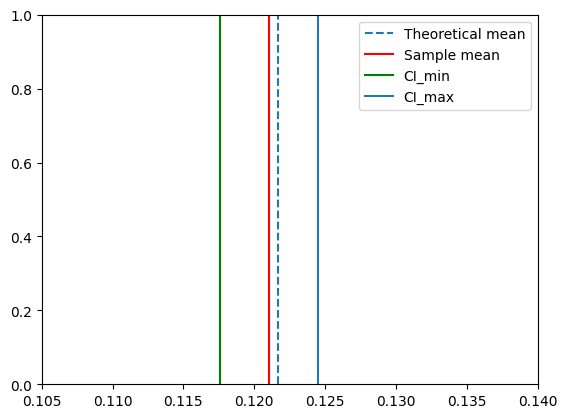

In [213]:
plt.axvline(0.12166106425295149, ymin=0,linestyle='--', label="Theoretical mean")
plt.axvline(sample_mean, label="Sample mean", color="red")
plt.axvline(CI_min, label="CI_min", color="green")
plt.axvline(CI_max, label="CI_max")
plt.xlim(0.105,0.14)
plt.legend()

#### Theoretical results

In [214]:
from math import factorial
A = 8*1
(A**m/factorial(m)) / (np.sum([A**i / factorial(i) for i in range(m+1)]))

np.float64(0.12166106425295149)

# Part 2
## a)

In [233]:
# Parameters
np.random.seed(30)
m = 10
lam = 8
k = 8
mean_arrivaltime = k/lam
mean_servicetime = 8

assert mean_arrivaltime == 1, "hehj"


# Run simulation
SIMS = []
for iter in range(10):
    # Store 
    servers = np.zeros(m)
    t = 0
    blocked_customers = 0
    

    N = 0
    while N < 10_000:
        # Get time for next arrival
        arrival_time = ss.erlang.rvs(a=k, scale=1/lam)
        t += arrival_time

        servers -= arrival_time
        servers = np.clip(servers, a_min=0, a_max=None)

        # Draw random service time
        service_time = np.random.exponential(mean_servicetime)

        # Check if enough servers
        mask = (servers == 0)
        if np.any(mask):
            idx = np.flatnonzero(mask)[0]
            servers[idx] = service_time
        else:
            blocked_customers += 1
        
        N += 1
    
    SIMS.append(blocked_customers/10_000)

SIMS, np.mean(SIMS)

([0.0787,
  0.0621,
  0.0602,
  0.0689,
  0.07,
  0.0702,
  0.0688,
  0.0625,
  0.0695,
  0.0667],
 np.float64(0.06776))

0.06395936651327426 0.07156063348672574 0.0076012669734514815


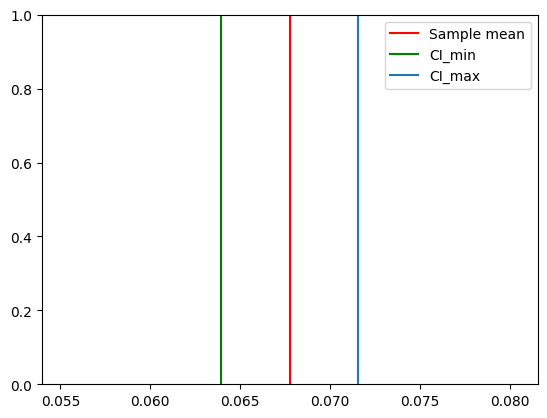

In [234]:
# Sample mean and variance
n = len(SIMS)
sample_mean = np.mean(SIMS)
sample_var = (np.sum(np.array(SIMS)**2)-n*sample_mean**2) * 1/(n - 1)
s_theta = np.sqrt(sample_var)

# Confidence interval
alpha = 0.05
CI_min = sample_mean + s_theta/np.sqrt(n)*ss.t.ppf(alpha/2, df=n-1)
CI_max = sample_mean + s_theta/np.sqrt(n)*ss.t.ppf(1-alpha/2, df=n-1)
print(CI_min, CI_max, (CI_max-CI_min))

plt.axvline(sample_mean, label="Sample mean", color="red")
plt.axvline(CI_min, label="CI_min", color="green")
plt.axvline(CI_max, label="CI_max")
plt.xlim(CI_min-0.01,CI_max+0.01)
plt.legend()

## b)

In [235]:
# Parameters
np.random.seed(30)
m = 10
p1 = 0.8
p2 = 0.2
lam1 = 0.8333
lam2 = 5.0
LAM = [lam1,lam2]
mean_arrivaltime = p1/lam1 + p2/lam2
mean_servicetime = 8


# Run simulation
SIMS = []
for iter in range(10):
    # Store 
    servers = np.zeros(m)
    t = 0
    blocked_customers = 0
    

    N = 0
    while N < 10_000:
        # Get time for next arrival
        d = np.random.choice([0,1],p=[p1,p2])
        arrival_time = np.random.exponential(1/LAM[d])
        t += arrival_time

        servers -= arrival_time
        servers = np.clip(servers, a_min=0, a_max=None)

        # Draw random service time
        service_time = np.random.exponential(mean_servicetime)

        # Check if enough servers
        mask = (servers == 0)
        if np.any(mask):
            idx = np.flatnonzero(mask)[0]
            servers[idx] = service_time
        else:
            blocked_customers += 1
        
        N += 1
    
    SIMS.append(blocked_customers/10_000)

SIMS, np.mean(SIMS)

([0.1422,
  0.1414,
  0.1427,
  0.1246,
  0.1501,
  0.1362,
  0.1286,
  0.1456,
  0.1381,
  0.1351],
 np.float64(0.13845999999999997))

0.13295529361810227 0.14396470638189768 0.011009412763795412


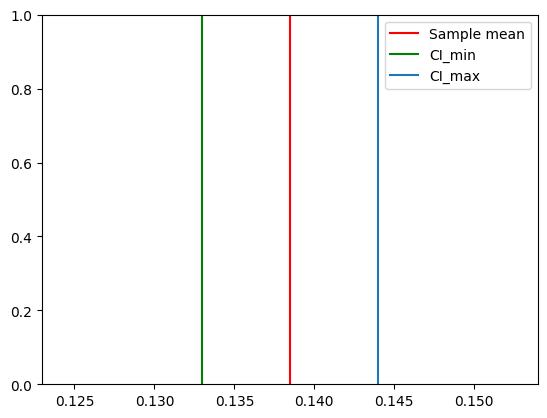

In [237]:
# Sample mean and variance
n = len(SIMS)
sample_mean = np.mean(SIMS)
sample_var = (np.sum(np.array(SIMS)**2)-n*sample_mean**2) * 1/(n - 1)
s_theta = np.sqrt(sample_var)

# Confidence interval
alpha = 0.05
CI_min = sample_mean + s_theta/np.sqrt(n)*ss.t.ppf(alpha/2, df=n-1)
CI_max = sample_mean + s_theta/np.sqrt(n)*ss.t.ppf(1-alpha/2, df=n-1)
print(CI_min, CI_max, (CI_max-CI_min))

plt.axvline(sample_mean, label="Sample mean", color="red")
plt.axvline(CI_min, label="CI_min", color="green")
plt.axvline(CI_max, label="CI_max")
plt.xlim(CI_min-0.01,CI_max+0.01)
plt.legend()

# Part 3
## a) constant service time

[0.1216, 0.1146, 0.1221, 0.127, 0.1165, 0.1262, 0.1229, 0.1309, 0.1283, 0.1204] 0.12305000000000002
0.11936311561815961 0.12673688438184041 0.007373768763680802


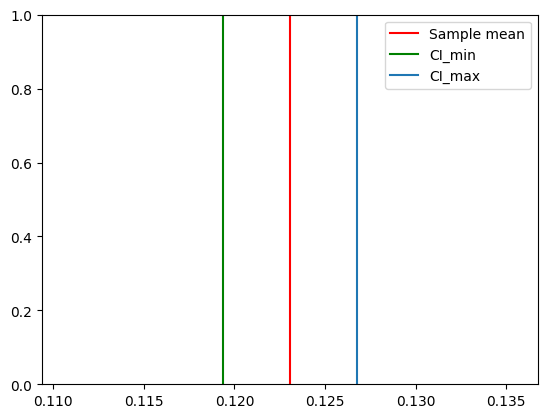

In [240]:
# Parameters
np.random.seed(30)
m = 10
mean_arrivaltime = 1


# Run simulation
SIMS = []
for k in range(10):
    # Store 
    servers = np.zeros(m)
    t = 0
    blocked_customers = 0
    

    N = 0
    while N < 10_000:
        # Get time for next arrival
        arrival_time = np.random.exponential(mean_arrivaltime)
        t += arrival_time

        servers -= arrival_time
        servers = np.clip(servers, a_min=0, a_max=None)

        # Draw random service time
        service_time = 8

        # Check if enough servers
        mask = (servers == 0)
        if np.any(mask):
            idx = np.flatnonzero(mask)[0]
            servers[idx] = service_time
        else:
            blocked_customers += 1
        
        N += 1
    
    SIMS.append(blocked_customers/10_000)

print(SIMS, np.mean(SIMS))

# Sample mean and variance
n = len(SIMS)
sample_mean = np.mean(SIMS)
sample_var = (np.sum(np.array(SIMS)**2)-n*sample_mean**2) * 1/(n - 1)
s_theta = np.sqrt(sample_var)

# Confidence interval
alpha = 0.05
CI_min = sample_mean + s_theta/np.sqrt(n)*ss.t.ppf(alpha/2, df=n-1)
CI_max = sample_mean + s_theta/np.sqrt(n)*ss.t.ppf(1-alpha/2, df=n-1)
print(CI_min, CI_max, CI_max-CI_min)

plt.axvline(sample_mean, label="Sample mean", color="red")
plt.axvline(CI_min, label="CI_min", color="green")
plt.axvline(CI_max, label="CI_max")
plt.xlim(CI_min-0.01,CI_max+0.01)
plt.legend()

## b) Pareto distributed

[0.0585, 0.0414, 0.0348, 0.0135, 0.1332, 0.0484, 0.0527, 0.0817, 0.063, 0.0481] 0.057530000000000005
0.03459381237822626 0.08046618762177374
0.04587237524354748


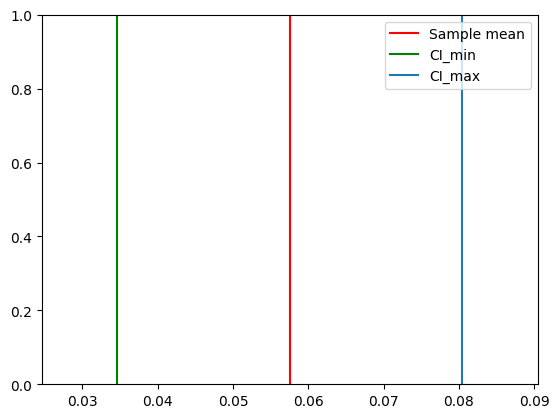

In [241]:
# Parameters
np.random.seed(30)
m = 10
mean_arrivaltime = 1

def pareto(k):
    # Run simulation
    SIMS = []
    for iter in range(10):
        # Store 
        servers = np.zeros(m)
        t = 0
        blocked_customers = 0
        

        N = 0
        while N < 10_000:
            # Get time for next arrival
            arrival_time = np.random.exponential(mean_arrivaltime)
            t += arrival_time

            servers -= arrival_time
            servers = np.clip(servers, a_min=0, a_max=None)

            # Draw random service time
            service_time = np.random.pareto(k)

            # Check if enough servers
            mask = (servers == 0)
            if np.any(mask):
                idx = np.flatnonzero(mask)[0]
                servers[idx] = service_time
            else:
                blocked_customers += 1
            
            N += 1
        
        SIMS.append(blocked_customers/10_000)

    print(SIMS, np.mean(SIMS))

    # Sample mean and variance
    n = len(SIMS)
    sample_mean = np.mean(SIMS)
    sample_var = (np.sum(np.array(SIMS)**2)-n*sample_mean**2) * 1/(n - 1)
    s_theta = np.sqrt(sample_var)

    # Confidence interval
    alpha = 0.05
    CI_min = sample_mean + s_theta/np.sqrt(n)*ss.t.ppf(alpha/2, df=n-1)
    CI_max = sample_mean + s_theta/np.sqrt(n)*ss.t.ppf(1-alpha/2, df=n-1)
    print(CI_min, CI_max)
    print(CI_max-CI_min)

    plt.axvline(sample_mean, label="Sample mean", color="red")
    plt.axvline(CI_min, label="CI_min", color="green")
    plt.axvline(CI_max, label="CI_max")
    plt.xlim(CI_min-0.01,CI_max+0.01)
    plt.legend()

pareto(k=1.05)
#pareto(k=2.05)

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] 0.0
0.0 0.0
0.0


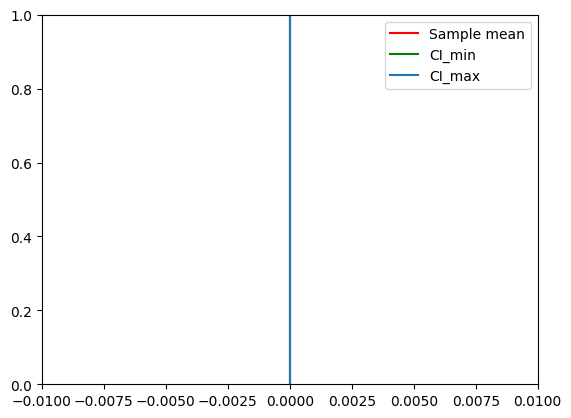

In [242]:
pareto(k=2.05)

## c) Choose two other distributions
#### 1) uniform between (0,15)

[0.0947, 0.0953, 0.1044, 0.1017, 0.1089, 0.1036, 0.0994, 0.0946, 0.1028, 0.0994] 0.10047999999999999
0.0971076403191691 0.10385235968083087 0.006744719361661766


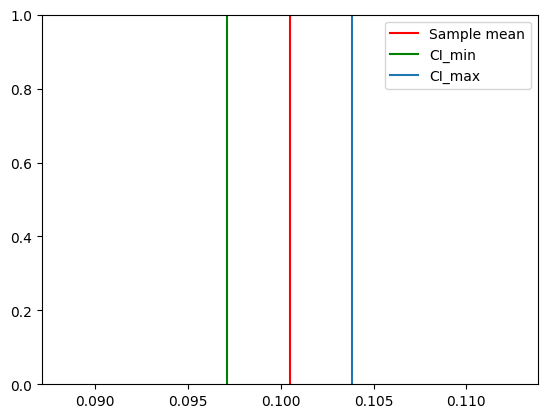

In [245]:
# Parameters
np.random.seed(30)
m = 10
mean_arrivaltime = 1
mean_servicetime = 8

# Run simulation
SIMS = []
for k in range(10):
    # Store 
    servers = np.zeros(m)
    t = 0
    blocked_customers = 0
    

    N = 0
    while N < 10_000:
        # Get time for next arrival
        arrival_time = np.random.exponential(mean_arrivaltime)
        t += arrival_time

        servers -= arrival_time
        servers = np.clip(servers, a_min=0, a_max=None)

        # Draw random service time
        service_time = np.random.uniform(0,15)

        # Check if enough servers
        mask = (servers == 0)
        if np.any(mask):
            idx = np.flatnonzero(mask)[0]
            servers[idx] = service_time
        else:
            blocked_customers += 1
        
        N += 1
    
    SIMS.append(blocked_customers/10_000)

print(SIMS, np.mean(SIMS))

# Sample mean and variance
n = len(SIMS)
sample_mean = np.mean(SIMS)
sample_var = (np.sum(np.array(SIMS)**2)-n*sample_mean**2) * 1/(n - 1)
s_theta = np.sqrt(sample_var)

# Confidence interval
alpha = 0.05
CI_min = sample_mean + s_theta/np.sqrt(n)*ss.t.ppf(alpha/2, df=n-1)
CI_max = sample_mean + s_theta/np.sqrt(n)*ss.t.ppf(1-alpha/2, df=n-1)
print(CI_min, CI_max, CI_max-CI_min)

plt.axvline(sample_mean, label="Sample mean", color="red")
plt.axvline(CI_min, label="CI_min", color="green")
plt.axvline(CI_max, label="CI_max")
plt.xlim(CI_min-0.01,CI_max+0.01)
plt.legend()


#### 2) Normal distributed with mean = 8 and sd = 2

[0.1114, 0.1199, 0.1216, 0.133, 0.1171, 0.1222, 0.1141, 0.1144, 0.1246, 0.1226] 0.12009
0.11561122714798366 0.12456877285201634 0.008957545704032677


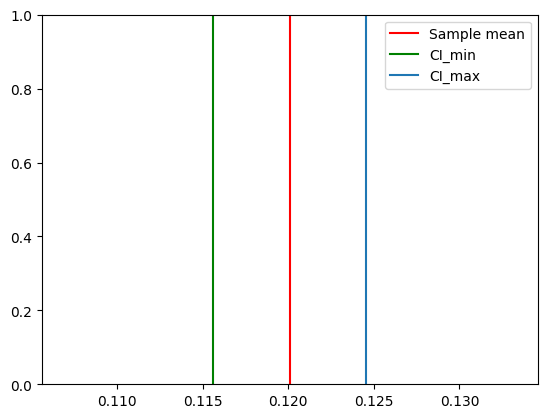

In [244]:
# Parameters
np.random.seed(30)
m = 10
mean_arrivaltime = 1
mean_servicetime = 8

# Run simulation
SIMS = []
for k in range(10):
    # Store 
    servers = np.zeros(m)
    t = 0
    blocked_customers = 0
    

    N = 0
    while N < 10_000:
        # Get time for next arrival
        arrival_time = np.random.exponential(mean_arrivaltime)
        t += arrival_time

        servers -= arrival_time
        servers = np.clip(servers, a_min=0, a_max=None)

        # Draw random service time
        service_time = np.random.normal(loc=8, scale=2)

        # Check if enough servers
        mask = (servers == 0)
        if np.any(mask):
            idx = np.flatnonzero(mask)[0]
            servers[idx] = service_time
        else:
            blocked_customers += 1
        
        N += 1
    
    SIMS.append(blocked_customers/10_000)

print(SIMS, np.mean(SIMS))

# Sample mean and variance
n = len(SIMS)
sample_mean = np.mean(SIMS)
sample_var = (np.sum(np.array(SIMS)**2)-n*sample_mean**2) * 1/(n - 1)
s_theta = np.sqrt(sample_var)

# Confidence interval
alpha = 0.05
CI_min = sample_mean + s_theta/np.sqrt(n)*ss.t.ppf(alpha/2, df=n-1)
CI_max = sample_mean + s_theta/np.sqrt(n)*ss.t.ppf(1-alpha/2, df=n-1)
print(CI_min, CI_max, CI_max-CI_min)

plt.axvline(sample_mean, label="Sample mean", color="red")
plt.axvline(CI_min, label="CI_min", color="green")
plt.axvline(CI_max, label="CI_max")
plt.xlim(CI_min-0.01,CI_max+0.01)
plt.legend()
